<a href="https://colab.research.google.com/github/rushinakhale115/NLP_Assignments/blob/main/NLP_Assignments/Ass_8_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install gensim scikit-learn matplotlib pandas

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

In [6]:
products = [
    "wireless bluetooth headphones",
    "noise cancelling earphones",
    "gaming laptop high performance",
    "lightweight running shoes",
    "sports shoes for running",
    "smartphone with high resolution camera",
    "android mobile phone fast processor",
    "fitness smartwatch heart rate monitor",
    "tablet with large display",
    "office chair ergonomic comfortable",
    "wireless mouse and keyboard combo",
    "gaming keyboard rgb lights",
    "dslr camera professional photography",
    "running shoes breathable mesh",
    "bluetooth speaker portable"
]

df = pd.DataFrame(products, columns=["product"])
print(df.head())

                          product
0   wireless bluetooth headphones
1      noise cancelling earphones
2  gaming laptop high performance
3       lightweight running shoes
4        sports shoes for running


In [9]:
def preprocess(text):
    return text.lower().split()

df["tokens"] = df["product"].apply(preprocess)

print(df.head())
model = Word2Vec(
    sentences=df["tokens"],
    vector_size=100,
    window=3,
    min_count=1,
    workers=4,
    epochs=100
)

print("Vocabulary size:", len(model.wv))



                          product                               tokens
0   wireless bluetooth headphones    [wireless, bluetooth, headphones]
1      noise cancelling earphones       [noise, cancelling, earphones]
2  gaming laptop high performance  [gaming, laptop, high, performance]
3       lightweight running shoes        [lightweight, running, shoes]
4        sports shoes for running        [sports, shoes, for, running]
Vocabulary size: 49


In [11]:
def sentence_vector(sentence):
    words = sentence.lower().split()
    vectors = []

    for word in words:
        if word in model.wv:
            vectors.append(model.wv[word])

    if len(vectors) == 0:
        return np.zeros(100)

    return np.mean(vectors, axis=0)

df["vector"] = df["product"].apply(sentence_vector)

print(df.head())

                          product                               tokens  \
0   wireless bluetooth headphones    [wireless, bluetooth, headphones]   
1      noise cancelling earphones       [noise, cancelling, earphones]   
2  gaming laptop high performance  [gaming, laptop, high, performance]   
3       lightweight running shoes        [lightweight, running, shoes]   
4        sports shoes for running        [sports, shoes, for, running]   

                                              vector  
0  [-0.00024981846, 0.0037576847, 0.006258573, 0....  
1  [-0.00035159662, 0.0044137635, -0.0042699943, ...  
2  [-0.0029727225, -0.0023742912, -0.001170561, -...  
3  [-0.0014102921, -3.759399e-05, 0.00031136815, ...  
4  [-0.005188239, 0.0022660932, 0.00090664765, -0...  


In [12]:
def semantic_search(query, top_k=5):
    query_vec = sentence_vector(query)

    similarities = []

    for vec in df["vector"]:
        score = cosine_similarity([query_vec], [vec])[0][0]
        similarities.append(score)

    df["similarity"] = similarities

    results = df.sort_values(by="similarity", ascending=False)

    print("\n🔍 Query:", query)
    print("\nTop Results:\n")

    for i, row in results.head(top_k).iterrows():
        print(f"{row['product']}  --> Score: {row['similarity']:.3f}")

In [13]:
semantic_search("comfortable running shoes")
semantic_search("bluetooth headphones")
semantic_search("gaming keyboard")
semantic_search("mobile phone camera")


🔍 Query: comfortable running shoes

Top Results:

running shoes breathable mesh  --> Score: 0.689
lightweight running shoes  --> Score: 0.653
sports shoes for running  --> Score: 0.542
office chair ergonomic comfortable  --> Score: 0.305
fitness smartwatch heart rate monitor  --> Score: 0.154

🔍 Query: bluetooth headphones

Top Results:

wireless bluetooth headphones  --> Score: 0.828
bluetooth speaker portable  --> Score: 0.459
wireless mouse and keyboard combo  --> Score: 0.128
gaming keyboard rgb lights  --> Score: 0.121
fitness smartwatch heart rate monitor  --> Score: 0.119

🔍 Query: gaming keyboard

Top Results:

gaming keyboard rgb lights  --> Score: 0.752
wireless mouse and keyboard combo  --> Score: 0.507
gaming laptop high performance  --> Score: 0.388
android mobile phone fast processor  --> Score: 0.244
tablet with large display  --> Score: 0.207

🔍 Query: mobile phone camera

Top Results:

android mobile phone fast processor  --> Score: 0.586
dslr camera professional phot

In [14]:
print("\nSimilar words to 'shoes':")
print(model.wv.most_similar("shoes"))

print("\nSimilar words to 'camera':")
print(model.wv.most_similar("camera"))


Similar words to 'shoes':
[('lights', 0.22177143394947052), ('portable', 0.21891766786575317), ('monitor', 0.19936099648475647), ('performance', 0.17625728249549866), ('heart', 0.16534389555454254), ('fast', 0.15239351987838745), ('fitness', 0.11573797464370728), ('phone', 0.10810114443302155), ('tablet', 0.10692667216062546), ('bluetooth', 0.10112819820642471)]

Similar words to 'camera':
[('professional', 0.1950102150440216), ('mobile', 0.18232440948486328), ('earphones', 0.15722374618053436), ('high', 0.15133945643901825), ('wireless', 0.08788424730300903), ('fast', 0.08746346831321716), ('running', 0.08141341060400009), ('lightweight', 0.07983735203742981), ('gaming', 0.07165650278329849), ('rate', 0.06624900549650192)]


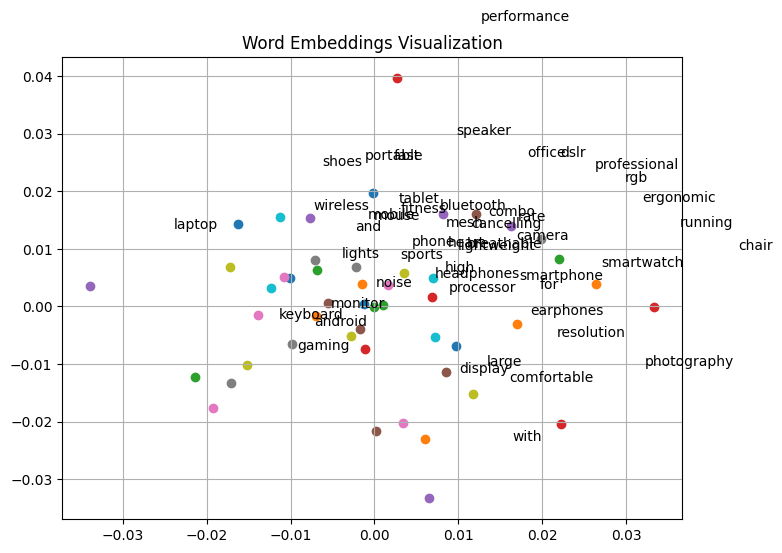

In [15]:
words = list(model.wv.index_to_key)
vectors = [model.wv[word] for word in words]

pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)

plt.figure(figsize=(8,6))

for i, word in enumerate(words):
    plt.scatter(reduced[i,0], reduced[i,1])
    plt.text(reduced[i,0]+0.01, reduced[i,1]+0.01, word)

plt.title("Word Embeddings Visualization")
plt.grid()
plt.show()

In [16]:
test_cases = [
    ("running shoes", "sports shoes for running"),
    ("bluetooth speaker", "bluetooth speaker portable"),
    ("office chair", "office chair ergonomic comfortable")
]

print("\nEvaluation:\n")

for query, expected in test_cases:
    query_vec = sentence_vector(query)

    best_product = None
    best_score = -1

    for product, vec in zip(df["product"], df["vector"]):
        score = cosine_similarity([query_vec], [vec])[0][0]

        if score > best_score:
            best_score = score
            best_product = product

    print(f"Query: {query}")
    print(f"Predicted: {best_product}")
    print(f"Expected : {expected}")
    print(f"Score    : {best_score:.3f}")
    print("-"*40)


Evaluation:

Query: running shoes
Predicted: lightweight running shoes
Expected : sports shoes for running
Score    : 0.811
----------------------------------------
Query: bluetooth speaker
Predicted: bluetooth speaker portable
Expected : bluetooth speaker portable
Score    : 0.826
----------------------------------------
Query: office chair
Predicted: office chair ergonomic comfortable
Expected : office chair ergonomic comfortable
Score    : 0.735
----------------------------------------
